# Free energy of a solid: harmonic vs quasiharmonic vs anharmonic

This notebook computes the free energy of fcc Al with four methods:

1. **Harmonic** — phonopy FC2 at the reference volume.
2. **Quasiharmonic** — `phonopy.qha.QHA` across a volume sweep.
3. **Anharmonic (dynaphopy)** — MD-projected renormalised harmonic, one *T* and a *T* grid.
4. **Anharmonic (calphy)** — Frenkel–Ladd thermodynamic integration (skipped if `lmp` is unavailable).

All four are entry points under `pyiron_workflow_atomistics.physics.free_energy`.

> **Defaults are tuned for teaching speed**, *not* publication accuracy. The final cell
> lists exactly which knobs to bump for production-grade results.


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.calculators.emt import EMT

from pyiron_workflow_atomistics.engine import ASEEngine, CalcInputStatic

# fcc Al conventional cell (phonopy primitivises to a 1-atom primitive).
structure = bulk("Al", "fcc", a=4.05, cubic=True)

ase_engine = ASEEngine(
    EngineInput=CalcInputStatic(),
    calculator=EMT(),
    working_directory="_runs",
)

# Small FC2 supercell (2x2x2 = 32 atoms) keeps wall time low for teaching.
fc2_sc = 2 * np.eye(3, dtype=int)

# 9-point T grid from 0 K to 800 K (100 K spacing) — coarse but adequate to
# eyeball the F(T)/S(T)/Cv(T) curves.
T_grid = np.arange(0, 801, 100)

print(f"structure: {structure.symbols}, n_atoms={len(structure)}")
print(f"T grid: {T_grid}")


structure: Al4, n_atoms=4
T grid: [  0 100 200 300 400 500 600 700 800]


## 2. Harmonic free energy

Fixed-volume FC2 phonons via phonopy. Returns `F(T)`, `S(T)`, `C_v(T)` at the input
reference volume. F at the lowest T is the zero-point energy.


mode=harmonic, n_atoms=4, n_primitive=1
F(0 K) = 0.0334 eV/atom (zero-point energy)
F(300 K) ≈ -0.0091 eV/atom


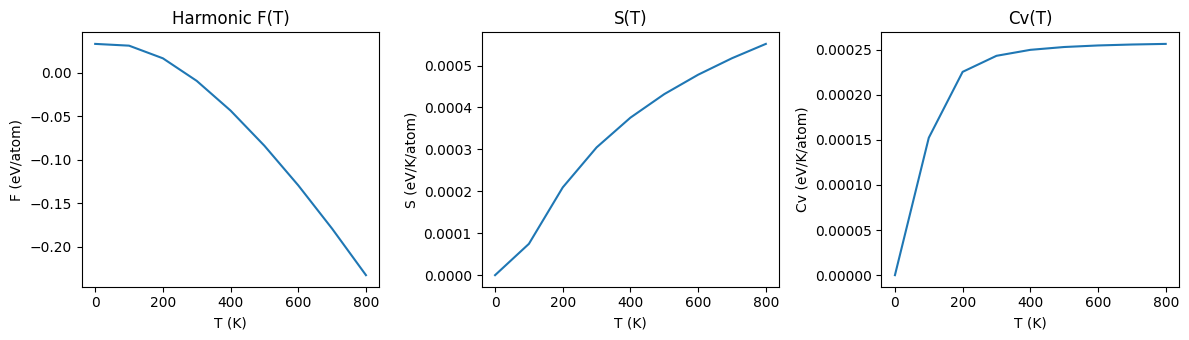

In [2]:
from pyiron_workflow_atomistics.physics.free_energy import harmonic_free_energy

wf_h = harmonic_free_energy(
    structure=structure,
    engine=ase_engine,
    fc2_supercell_matrix=fc2_sc,
    temperatures=T_grid,
    working_directory="_runs",
    subdir="harmonic",
)
out_harm = wf_h.run()
out_harm = out_harm["free_energy_output"] if isinstance(out_harm, dict) else out_harm

print(f"mode={out_harm.mode}, n_atoms={out_harm.n_atoms}, n_primitive="
      f"{out_harm.report['n_atoms_primitive']}")
print(f"F(0 K) = {out_harm.free_energy_array[0]:.4f} eV/atom (zero-point energy)")
print(f"F(300 K) ≈ {np.interp(300, out_harm.temperature_array, out_harm.free_energy_array):.4f} eV/atom")

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(12, 3.5))
a1.plot(out_harm.temperature_array, out_harm.free_energy_array)
a1.set_xlabel("T (K)"); a1.set_ylabel("F (eV/atom)"); a1.set_title("Harmonic F(T)")
a2.plot(out_harm.temperature_array, out_harm.entropy_array)
a2.set_xlabel("T (K)"); a2.set_ylabel("S (eV/K/atom)"); a2.set_title("S(T)")
a3.plot(out_harm.temperature_array, out_harm.heat_capacity_array)
a3.set_xlabel("T (K)"); a3.set_ylabel("Cv (eV/K/atom)"); a3.set_title("Cv(T)")
plt.tight_layout(); plt.show()


## 3. Quasiharmonic free energy (QHA)

Volume sweep + per-volume harmonic free energy → `phonopy.qha.QHA` gives
`G(T,P)`, `V*(T,P)`, `B(T,P)`, `α(T,P)`. At `pressure=0`, `gibbs_free_energy_array`
is the Helmholtz free energy at the thermally expanded volume.


mode=qha
V*(0 K)   = 15.9840 Å³/atom
V*(800 K) = 16.2834 Å³/atom
α(300 K)  ≈ 2.488e-05 1/K


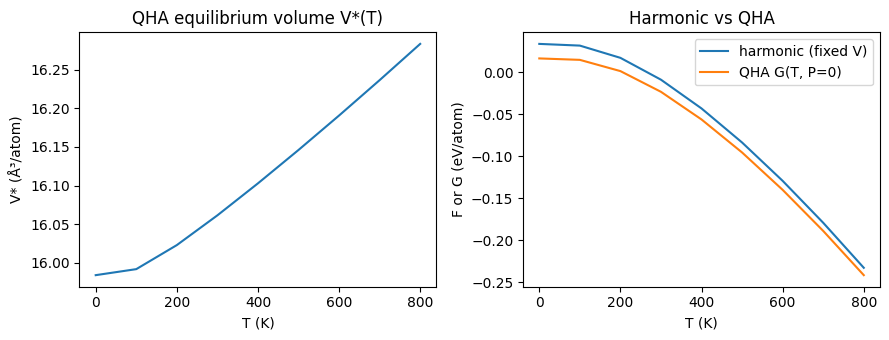

In [3]:
from pyiron_workflow_atomistics.physics.free_energy import quasiharmonic_free_energy

wf_q = quasiharmonic_free_energy(
    structure=structure,
    engine=ase_engine,
    fc2_supercell_matrix=fc2_sc,
    temperatures=T_grid,
    strain_range=(-0.03, 0.03),
    num_volumes=5,        # teaching default; bump to >=7 for production
    pressure=0.0,         # GPa
    working_directory="_runs",
    subdir="qha",
)
out_qha = wf_q.run()
out_qha = out_qha["free_energy_output"] if isinstance(out_qha, dict) else out_qha

print(f"mode={out_qha.mode}")
print(f"V*(0 K)   = {out_qha.equilibrium_volume_array[0]:.4f} Å³/atom")
print(f"V*(800 K) = {out_qha.equilibrium_volume_array[-1]:.4f} Å³/atom")
print(f"α(300 K)  ≈ {np.interp(300, out_qha.temperature_array, out_qha.thermal_expansion_array):.3e} 1/K")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.5))
a1.plot(out_qha.temperature_array, out_qha.equilibrium_volume_array)
a1.set_xlabel("T (K)"); a1.set_ylabel("V* (Å³/atom)"); a1.set_title("QHA equilibrium volume V*(T)")
a2.plot(out_harm.temperature_array, out_harm.free_energy_array, label="harmonic (fixed V)")
a2.plot(out_qha.temperature_array, out_qha.gibbs_free_energy_array, label="QHA G(T, P=0)")
a2.set_xlabel("T (K)"); a2.set_ylabel("F or G (eV/atom)"); a2.legend()
a2.set_title("Harmonic vs QHA")
plt.tight_layout(); plt.show()


## 4. Anharmonic free energy (dynaphopy, single *T*)

MD trajectory + dynaphopy projection at one temperature gives the *renormalised*
harmonic spectrum, which we sum into a Bose–Einstein free energy. Captures
soft-mode renormalisation at the cost of one finite-*T* MD run.


No velocity provided! calculating it from coordinates...
MD cell size relation: [2 2 2]
Using 2000 steps
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector


Harmonic frequencies (THz):
[-1.51598875e-06 -1.50070131e-06 -1.48068886e-06  9.15974998e+00
  9.15974998e+00  9.15974998e+00  9.15974998e+00  9.15974998e+00
  9.15974998e+00  1.38426869e+01  1.38426869e+01  1.38426869e+01]



Peak # 1
----------------------------------------------
Width                             0.066196 THz
Position                         19.538361 THz
Area (<K>)    (Lorentzian)        0.297455 eV
Area (<K>)    (Total)             9.244020 eV
<|dQ/dt|^2>                       0.594909 eV
Base line                         0.220904 eV * ps
Maximum height                    2.860689 eV * ps
Fitting global error              0.015406
Frequency shift                  19.538362 THz

Peak # 2
----------------------------------------------
Width                             0.066196 THz
Position                         19.538361 THz
Area (<K>)    (Lorentzian)        0.297455 eV
Area (<K>)    (Total)             9.244020 eV
<|dQ/dt|^2>                       0.594909 eV
Base line                         0.220904 eV * ps
Maximum height                    2.860689 eV * ps
Fitting global error              0.015406
Frequency shift                  19.538362 THz

Peak # 3
----------------------------

Harmonic frequencies (THz):
[ 2.88233472  2.88233472  3.6112648   8.72841362  8.72841362  9.12606033
  9.12606033  9.74652293  9.74652293 12.96399069 13.49596901 13.49596901]


Projecting into phonon mode
Projecting into wave vector
warning! This wave vector is not a commensurate q-point in MD supercell


...

Projecting into phonon mode
Projecting into wave vector
warning! This wave vector is not a commensurate q-point in MD supercell


Harmonic frequencies (THz):
[ 4.65181292  6.36847182  6.36847182  6.50384256  6.7813565   8.17590276
  8.17590276  9.13840528 11.69068494 12.63111214 12.63111214 12.97626768]


Projecting into phonon mode
Projecting into wave vector
warning! This wave vector is not a commensurate q-point in MD supercell


Harmonic frequencies (THz):
[ 4.65181292  6.36847182  6.36847182  6.50384256  6.7813565   8.17590276
  8.17590276  9.13840528 11.69068494 12.63111214 12.63111214 12.97626768]


Harmonic frequencies (THz):
[ 4.65181292  6.36847182  6.36847182  6.50384256  6.7813565   8.17590276
  8.17590276  9.13840528 11.69068494 12.63111214 12.63111214 12.97626768]

Peak # 1
----------------------------------------------
Width                             0.050020 THz
Position                         30.361187 THz
Area (<K>)    (Lorentzian)        0.164609 eV
Area (<K>)    (Total)            10.529611 eV
<|dQ/dt|^2>                       0.329217 eV
Base line                         0.258425 eV * ps
Maximum height                    2.095023 eV * ps
Fitting global error              0.023055
Frequency shift                  25.709374 THz

Peak # 2
----------------------------------------------
Width                             0.039464 THz
Position                         12.593752 THz
Area (<K>)    (Lorentzian)        0.063935 eV
Area (<K>)    (Total)            10.235374 eV
<|dQ/dt|^2>                       0.127870 eV
Base line                         0.254021 eV * ps
Maxi

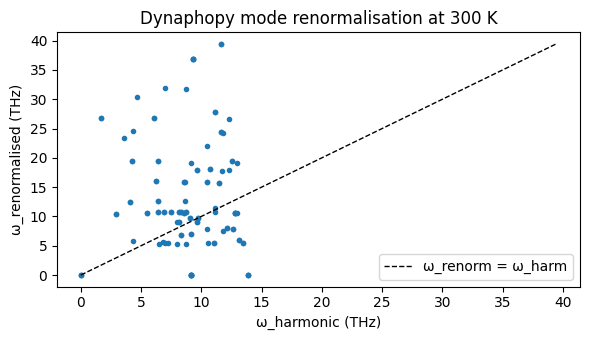

In [4]:
from pyiron_workflow_atomistics.physics.free_energy import (
    anharmonic_free_energy_dynaphopy,
)

wf_a = anharmonic_free_energy_dynaphopy(
    structure=structure,
    engine=ase_engine,
    fc2_supercell_matrix=fc2_sc,
    temperature=300.0,
    production_steps=2000,    # teaching default; bump to >=30_000 for production
    q_mesh=(5, 5, 5),         # teaching default; bump to (11, 11, 11) or denser
    working_directory="_runs",
    subdir="anharmonic_T300",
)
out_anh_T = wf_a.run()
out_anh_T = out_anh_T["free_energy_output"] if isinstance(out_anh_T, dict) else out_anh_T

F_harm_300 = float(np.interp(300.0, out_harm.temperature_array, out_harm.free_energy_array))
print(f"F_harmonic(300 K)         = {F_harm_300:.4f} eV/atom")
print(f"F_anharm (dynaphopy 300K) = {out_anh_T.free_energy:.4f} eV/atom")
print(f"Δ (anharm - harm)         = {out_anh_T.free_energy - F_harm_300:+.4f} eV/atom")
print(f"n_guarded_modes           = {out_anh_T.report.get('n_guarded_modes', 'n/a')}")

# Mode-by-mode renormalisation: ω_harmonic vs ω_renormalised
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(out_anh_T.harmonic_frequencies.ravel(),
        out_anh_T.renormalised_frequencies.ravel(), "o", ms=3)
lim = (
    float(min(out_anh_T.harmonic_frequencies.min(), out_anh_T.renormalised_frequencies.min())),
    float(max(out_anh_T.harmonic_frequencies.max(), out_anh_T.renormalised_frequencies.max())),
)
ax.plot(lim, lim, "k--", lw=1, label="ω_renorm = ω_harm")
ax.set_xlabel("ω_harmonic (THz)")
ax.set_ylabel("ω_renormalised (THz)")
ax.set_title("Dynaphopy mode renormalisation at 300 K")
ax.legend()
plt.tight_layout(); plt.show()


## 5. Anharmonic free energy (dynaphopy, T-grid)

Renormalised-harmonic at each *T*, stacked into `F(T)` with `S(T)`/`Cv(T)`
recovered by finite-differencing. Each *T* is an independent MD + dynaphopy
projection, so this scales linearly with the number of temperatures.


In [5]:
from pyiron_workflow_atomistics.physics.free_energy import (
    anharmonic_free_energy_dynaphopy_tdi,
)

wf_tdi = anharmonic_free_energy_dynaphopy_tdi(
    structure=structure,
    engine=ase_engine,
    fc2_supercell_matrix=fc2_sc,
    temperatures=(300.0, 600.0),     # teaching default; bump to (200, 400, 600, 800) for a finer sweep
    production_steps=2000,           # teaching default
    q_mesh=(5, 5, 5),                # teaching default
    working_directory="_runs",
    subdir="anharmonic_tdi",
)
out_anh_tdi = wf_tdi.run()
out_anh_tdi = out_anh_tdi["free_energy_output"] if isinstance(out_anh_tdi, dict) else out_anh_tdi

print(f"mode={out_anh_tdi.mode}")
print(f"temperatures = {out_anh_tdi.temperature_array}")
print(f"F_anharm(T)  = {out_anh_tdi.free_energy_array}")


No velocity provided! calculating it from coordinates...
MD cell size relation: [2 2 2]
Using 2000 steps
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector


Harmonic frequencies (THz):
[-1.51598875e-06 -1.50070131e-06 -1.48068886e-06  9.15974998e+00
  9.15974998e+00  9.15974998e+00  9.15974998e+00  9.15974998e+00
  9.15974998e+00  1.38426869e+01  1.38426869e+01  1.38426869e+01]



Peak # 1
----------------------------------------------
Width                             0.149055 THz
Position                         24.928802 THz
Area (<K>)    (Lorentzian)        0.675197 eV
Area (<K>)    (Total)            10.871647 eV
<|dQ/dt|^2>                       1.350393 eV
Base line                         0.254944 eV * ps
Maximum height                    2.883798 eV * ps
Fitting global error              0.008936
Frequency shift                  24.928803 THz

Peak # 2
----------------------------------------------
Width                             0.149055 THz
Position                         24.928802 THz
Area (<K>)    (Lorentzian)        0.675197 eV
Area (<K>)    (Total)            10.871647 eV
<|dQ/dt|^2>                       1.350393 eV
Base line                         0.254944 eV * ps
Maximum height                    2.883798 eV * ps
Fitting global error              0.008936
Frequency shift                  24.928803 THz

Peak # 3
----------------------------

Harmonic frequencies (THz):
[ 2.88233472  2.88233472  3.6112648   8.72841362  8.72841362  9.12606033
  9.12606033  9.74652293  9.74652293 12.96399069 13.49596901 13.49596901]


Projecting into phonon mode
Projecting into wave vector
warning! This wave vector is not a commensurate q-point in MD supercell


...

Projecting into phonon mode
Projecting into wave vector
warning! This wave vector is not a commensurate q-point in MD supercell


Harmonic frequencies (THz):
[ 4.65181292  6.36847182  6.36847182  6.50384256  6.7813565   8.17590276
  8.17590276  9.13840528 11.69068494 12.63111214 12.63111214 12.97626768]


Projecting into phonon mode
Projecting into wave vector
warning! This wave vector is not a commensurate q-point in MD supercell


Harmonic frequencies (THz):
[ 4.65181292  6.36847182  6.36847182  6.50384256  6.7813565   8.17590276
  8.17590276  9.13840528 11.69068494 12.63111214 12.63111214 12.97626768]


Harmonic frequencies (THz):
[ 4.65181292  6.36847182  6.36847182  6.50384256  6.7813565   8.17590276
  8.17590276  9.13840528 11.69068494 12.63111214 12.63111214 12.97626768]

Peak # 1
----------------------------------------------
Width                             0.049019 THz
Position                         10.643613 THz
Area (<K>)    (Lorentzian)        0.099559 eV
Area (<K>)    (Total)            10.736799 eV
<|dQ/dt|^2>                       0.199118 eV
Base line                         0.264508 eV * ps
Maximum height                    1.293007 eV * ps
Fitting global error              0.035097
Frequency shift                   5.991801 THz

Peak # 2
----------------------------------------------
Width                             0.152246 THz
Position                          7.624228 THz
Area (<K>)    (Lorentzian)        0.234839 eV
Area (<K>)    (Total)            10.745554 eV
<|dQ/dt|^2>                       0.469677 eV
Base line                         0.262627 eV * ps
Maxi

## 6. Anharmonic free energy (calphy, Frenkel–Ladd TI)

Full anharmonic free energy via thermodynamic integration from an Einstein-crystal
reference. Requires the `[free-energy]` extras *and* a working `lmp` binary on `PATH`.
The cell is wrapped in `try/except` so it skips gracefully when either is missing.


In [6]:
# Section 6 — Anharmonic (calphy TI) — needs [free-energy] extras + lmp on PATH
out_calphy = None
try:
    from shutil import which
    if which("lmp") is None:
        raise RuntimeError("`lmp` binary not on PATH")
    from pyiron_workflow_lammps.engine import LammpsEngine
    from pyiron_workflow_atomistics.physics.free_energy import (
        LammpsPotential,
        reversible_scaling_temperature,
    )
    lammps_engine = LammpsEngine(command="lmp")
    potential = LammpsPotential(
        pair_style="eam/alloy",
        pair_coeff="* * Al99.eam.alloy Al",
        potential_file="Al99.eam.alloy",
    )
    wf_c = reversible_scaling_temperature(
        structure=structure,
        lammps_engine=lammps_engine,
        potential=potential,
        temperature_range=(200.0, 600.0),
        reference_phase="solid",
        working_directory="_runs",
        subdir="calphy_ts",
    )
    out_calphy = wf_c.run()
    out_calphy = out_calphy["free_energy_output"] if isinstance(out_calphy, dict) else out_calphy
    print(f"calphy F(300 K) = "
          f"{np.interp(300, out_calphy.temperature_array, out_calphy.free_energy_array):.4f} eV/atom")
except Exception as exc:
    print(f"calphy step skipped: {exc}")


calphy step skipped: `lmp` binary not on PATH


## 7. Composite overlay — `F(T)` from every available method

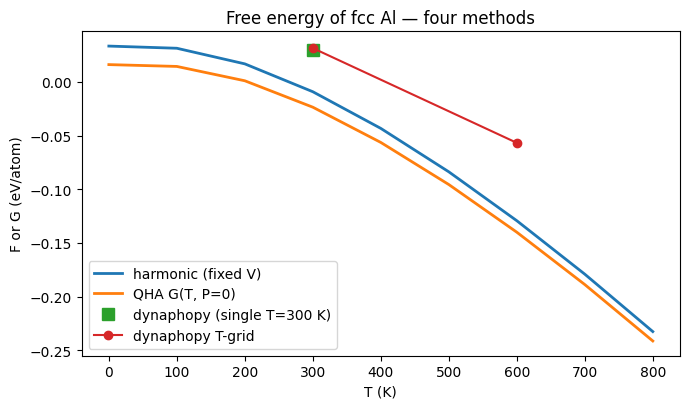

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.2))

ax.plot(out_harm.temperature_array, out_harm.free_energy_array,
        label="harmonic (fixed V)", lw=2)
ax.plot(out_qha.temperature_array, out_qha.gibbs_free_energy_array,
        label="QHA G(T, P=0)", lw=2)

# Single-T anharmonic point
ax.plot([out_anh_T.temperature], [out_anh_T.free_energy], "s",
        ms=9, label="dynaphopy (single T=300 K)")

# T-grid anharmonic curve
ax.plot(out_anh_tdi.temperature_array, out_anh_tdi.free_energy_array, "o-",
        label="dynaphopy T-grid")

if out_calphy is not None and out_calphy.temperature_array is not None:
    ax.plot(out_calphy.temperature_array, out_calphy.free_energy_array,
            label="calphy TI", lw=2)

ax.set_xlabel("T (K)"); ax.set_ylabel("F or G (eV/atom)")
ax.set_title("Free energy of fcc Al — four methods")
ax.legend()
plt.tight_layout(); plt.show()


## Notes — what each curve captures, and how to push to production

### Physical interpretation

- **Harmonic** uses a fixed reference volume — it tends to *over*estimate `F` at high `T`
  because the lattice cannot expand with temperature. Best for `T ≲ Θ_D/2`.
- **Quasiharmonic (QHA)** lets the lattice expand isobarically; the QHA curve should
  fall *below* the harmonic curve at high `T`. Captures thermal expansion exactly,
  but still uses harmonic phonons at each volume.
- **Dynaphopy renormalised** captures finite-T soft-mode renormalisation through the
  MD-projected spectrum, at fixed reference volume. Combine with QHA in a follow-up
  workflow to get *both* thermal expansion *and* mode renormalisation.
- **Calphy TI** is the reference: full classical anharmonicity via Frenkel–Ladd
  thermodynamic integration. Most expensive, no harmonic approximation anywhere.

### Production knobs

The defaults above are tuned for fast execution under CI (~10 min total). For
publication-grade accuracy bump the following:

| section                       | knob                 | teaching | production              |
|-------------------------------|----------------------|----------|-------------------------|
| Harmonic / QHA                | `T_grid`             | 9 pts    | `np.arange(0, 1001, 50)` (21 pts) |
| Harmonic / QHA                | `fc2_supercell_matrix` | 2x2x2 (32 at) | 3x3x3 (108 at) or 4x4x4 (256 at) |
| QHA                           | `num_volumes`        | 5        | 7–9                     |
| Dynaphopy (single T + T-grid) | `production_steps`   | 2000     | >=30_000                |
| Dynaphopy (single T + T-grid) | `q_mesh`             | (5,5,5)  | (11,11,11) or denser    |
| Dynaphopy T-grid              | `temperatures`       | 2 pts    | >=4 (e.g. 200/400/600/800) |
| Calphy TI                     | `temperature_range`  | 200–600  | full range of interest  |

For genuinely large supercells, you will also want to parallelise the dynaphopy MD
trajectories per *T* — each one is independent.
